In [2]:
import sys
import pandas as pd
sys.path.append("..")
from utils.market_data import get_candles

In [37]:
from datetime import date

ticker1 = "SBER"
ticker1_api_params = ["stock", "shares", "TQBR"]

ticker2 = "SRM6"
ticker2_api_params = ["futures", "forts", "RFUD"]

start_date = date(2026, 1, 2)
end_date = date(2026, 5, 23)

In [38]:
df1 = get_candles(ticker1, start_date, end_date, engine=ticker1_api_params[0], market=ticker1_api_params[1], board=ticker1_api_params[2], interval=10)
df2 = get_candles(ticker2, start_date, end_date, engine=ticker2_api_params[0], market=ticker2_api_params[1], board=ticker2_api_params[2], interval=10)

print(df1.head(1))
print(df2.head(1))

                      open  close   high    low       value  volume  \
timestamp                                                             
2026-01-05 06:50:00  300.0  300.0  300.0  300.0  21804600.0   72682   

                                     end  
timestamp                                 
2026-01-05 06:50:00  2026-01-05 06:59:59  
                      open  close   high    low  value  volume  \
timestamp                                                        
2026-01-05 09:00:00  32033  31901  32033  31899      0      71   

                                     end  
timestamp                                 
2026-01-05 09:00:00  2026-01-05 09:09:59  


In [47]:
df1.sort_values(by="timestamp", inplace=True)
df2.sort_values(by="timestamp", inplace=True)

df = pd.merge_asof(
    df1,
    df2,
    left_on="timestamp",
    right_on="timestamp",
    direction="nearest",
    tolerance=pd.Timedelta("5m")
)
df.head(1)

,timestamp,open_x,close_x,high_x,low_x,value_x,volume_x,end_x,open_y,close_y,high_y,low_y,value_y,volume_y,end_y
0,2026-01-05 06:50:00,300.0,300.0,300.0,300.0,21804600.0,72682,2026-01-05 06:59:59,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [48]:
df = df[["timestamp", "close_x", "close_y"]]
df["spread"] = df["close_y"] - df["close_x"]

Text(0.5, 1.0, 'Spread between SBER and SRM6')

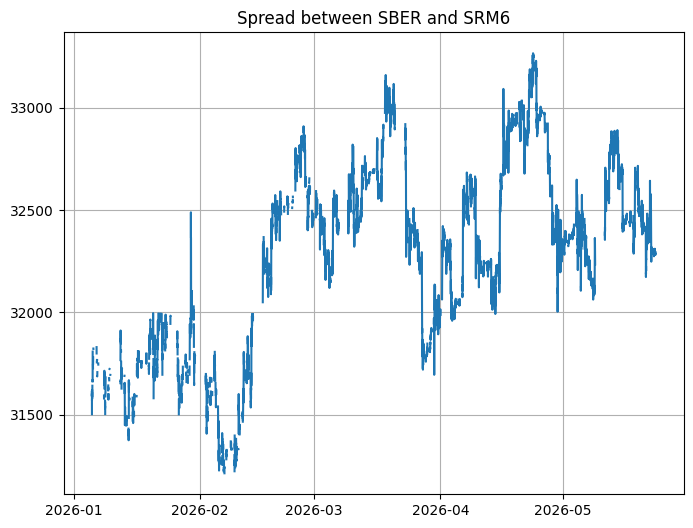

In [49]:
from matplotlib import pyplot as plt

fig = plt.figure(figsize=(8,6))
plt.plot(df['timestamp'], df['spread'])
plt.grid()
plt.title(f"Spread between {ticker1} and {ticker2}")

In [50]:
window=40
df['rolling_mean'] = df['spread'].rolling(window=window).mean()
df['rolling_std'] = df['spread'].rolling(window=window).std()

df['z_score'] = (df['spread'] - df['rolling_mean'])/df['rolling_std']

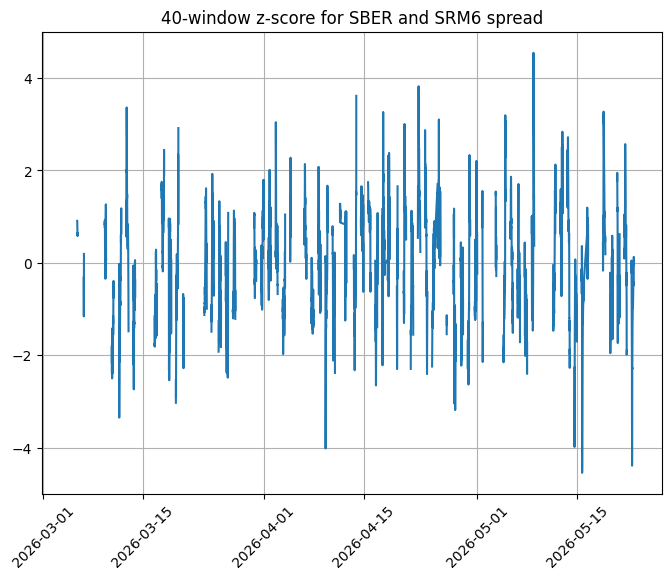

In [51]:
fig = plt.figure(figsize=(8,6))

plt.plot(df['timestamp'], df['z_score'])
plt.xticks(rotation=45)
plt.title(f"{window}-window z-score for {ticker1} and {ticker2} spread")
plt.grid()
plt.show()

In [54]:
backtest_df = df[['timestamp', ]].dropna().copy()
backtest_df.head()

,timestamp,close_x,close_y,spread,rolling_mean,rolling_std,z_score
4827,2026-03-04 19:00:00,311.38,32513.0,32201.62,32217.72450,50.540157,-0.318648
4926,2026-03-05 18:30:00,315.11,32855.0,32539.89,32418.55400,133.272146,0.910438
4927,2026-03-05 18:40:00,315.42,32860.0,32544.58,32425.50125,132.392815,0.899435
4928,2026-03-05 19:00:00,315.17,32855.0,32539.83,32432.08125,131.340524,0.820377
4929,2026-03-05 19:10:00,315.07,32855.0,32539.93,32438.61450,130.003010,0.779332
